# Notebook 04 — Phân tích Feature

File này gồm 2 phần:

**Phần 1 — Feature thống kê**
- Tính 3 chỉ số: Entropy, Burstiness, Độ dài câu trung bình
- Boxplot so sánh Human vs AI (EN và VI)
- Bảng mean/std theo nhóm

**Phần 2 — Attention Visualization**
- Load cả 2 model đã train (XLM-R và Hybrid)
- Visualize token nào model chú ý khi phân loại
- So sánh 2 model nhìn vào những token khác nhau không

In [1]:
!pip install transformers torch pandas numpy matplotlib seaborn underthesea -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 51.3 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 52.9 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 64.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numb

In [2]:
# ═══════════════════════════════════════════════════════════════════
# IMPORT & CẤU HÌNH
# ═══════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import math
from collections import Counter
from tqdm import tqdm

import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from underthesea import word_tokenize

# ── Đường dẫn model ──────────────────────────────────────────────
# Model 1: XLM-RoBERTa (từ notebook 02)
XLM_MODEL_DIR = "/kaggle/input/datasets/cminhnguyndsdsds/xlmroberta-rdrop"

# Model 2: Hybrid — RoBERTa (EN) và PhoBERT (VI) (từ notebook 03)
RO_MODEL_DIR  = "/kaggle/input/datasets/minhbodoi/hybrid-rdrop/roberta"
PH_MODEL_DIR  = "/kaggle/input/datasets/minhbodoi/hybrid-rdrop/phobert"

# ── Đường dẫn dữ liệu ────────────────────────────────────────────
TEST_EN_PATH = "/kaggle/input/datasets/cminhnguyndsdsds/faidset-processed/test_en.csv"
TEST_VI_PATH = "/kaggle/input/datasets/cminhnguyndsdsds/faidset-processed/test_vi.csv"

# ── Số mẫu ───────────────────────────────────────────────────────
N_STAT_SAMPLES = 3000   # Phần 1: tính feature thống kê
N_VIS_SAMPLES  = 5      # Phần 2: visualize attention từng mẫu
N_TOP_SAMPLES  = 200    # Phần 2: tổng hợp top tokens

SEED = 42
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [3]:
# ═══════════════════════════════════════════════════════════════════
# LOAD DỮ LIỆU TEST
# ═══════════════════════════════════════════════════════════════════
test_en_df = pd.read_csv(TEST_EN_PATH, encoding="utf-8-sig")
test_vi_df = pd.read_csv(TEST_VI_PATH, encoding="utf-8-sig")
print(f"Test EN: {len(test_en_df):,} mẫu  |  Test VI: {len(test_vi_df):,} mẫu")

def sample_balanced(df, n, seed=SEED):
    """Lấy n/2 mẫu Human và n/2 mẫu AI."""
    half  = n // 2
    human = df[df["label"] == 0].sample(min(half, (df["label"]==0).sum()), random_state=seed)
    ai    = df[df["label"] == 1].sample(min(half, (df["label"]==1).sum()), random_state=seed)
    return pd.concat([human, ai]).reset_index(drop=True)

# Tập cho Phần 1 (thống kê)
sample_en  = sample_balanced(test_en_df, N_STAT_SAMPLES)
sample_vi  = sample_balanced(test_vi_df, N_STAT_SAMPLES)
sample_all = pd.concat([sample_en, sample_vi]).reset_index(drop=True)

print(f"\nMẫu phân tích — EN: {len(sample_en)} | VI: {len(sample_vi)}")

Test EN: 62,621 mẫu  |  Test VI: 3,278 mẫu

Mẫu phân tích — EN: 3000 | VI: 2820


---
## Phần 1 — Feature Thống kê
Trả lời: *"Văn bản Human và AI khác nhau về mặt ngôn ngữ như thế nào?"*

In [4]:
# ═══════════════════════════════════════════════════════════════════
# ĐỊNH NGHĨA 3 HÀM TÍNH FEATURE
# ═══════════════════════════════════════════════════════════════════

def compute_entropy(text):
    """
    Entropy đo độ đa dạng từ vựng.
    H = -sum(p(w) * log2(p(w)))
    AI thường cao hơn (từ phong phú, đều đặn).
    Người thật thường thấp hơn (ít từ, lặp nhiều).
    """
    words = re.findall(r'\b\w+\b', text.lower())
    if not words:
        return 0.0
    counts = Counter(words)
    total  = len(words)
    return -sum((c/total) * math.log2(c/total) for c in counts.values())


def compute_burstiness(text):
    """
    Burstiness đo mức độ lặp từ theo cụm.
    B = (std - mean) / (std + mean)  của khoảng cách giữa
    các lần xuất hiện của từng từ.
    B gần 1  → bùng phát (người thật).
    B gần -1 → phân phối đều (AI).
    """
    words = re.findall(r'\b\w+\b', text.lower())
    if len(words) < 5:
        return 0.0
    positions = {}
    for i, w in enumerate(words):
        positions.setdefault(w, []).append(i)
    gaps = []
    for pos_list in positions.values():
        if len(pos_list) > 1:
            gaps.extend([pos_list[i+1] - pos_list[i] for i in range(len(pos_list)-1)])
    if len(gaps) < 2:
        return 0.0
    mu, std = np.mean(gaps), np.std(gaps)
    return (std - mu) / (std + mu) if (std + mu) != 0 else 0.0


def compute_avg_sentence_length(text):
    """
    Độ dài câu trung bình (số từ/câu).
    AI thường viết câu dài, đều.
    Người thật hay viết câu ngắn xen lẫn câu dài.
    """
    sentences = [s.strip() for s in re.split(r'[.!?]+', text) if s.strip()]
    if not sentences:
        return 0.0
    return np.mean([len(re.findall(r'\b\w+\b', s)) for s in sentences])


print("Đã định nghĩa 3 hàm tính feature.")

Đã định nghĩa 3 hàm tính feature.


In [5]:
# ═══════════════════════════════════════════════════════════════════
# TÍNH 3 FEATURE CHO TOÀN BỘ MẪU
# ═══════════════════════════════════════════════════════════════════
def compute_features(df):
    results = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Tính features"):
        text = str(row["text"])
        results.append({
            "label":           row["label"],
            "language":        row["language"],
            "entropy":         compute_entropy(text),
            "burstiness":      compute_burstiness(text),
            "avg_sent_length": compute_avg_sentence_length(text),
        })
    return pd.DataFrame(results)

feat_df = compute_features(sample_all)
feat_df["label_name"] = feat_df["label"].map({0: "Human", 1: "AI"})

print("\n━━━ BẢNG THỐNG KÊ FEATURE (mean ± std) ━━━")
feature_cols = ["entropy", "burstiness", "avg_sent_length"]
summary = feat_df.groupby(["language", "label_name"])[feature_cols].agg(["mean", "std"]).round(4)
print(summary.to_string())

Tính features: 100%|██████████| 5820/5820 [00:02<00:00, 2011.07it/s]


━━━ BẢNG THỐNG KÊ FEATURE (mean ± std) ━━━
                    entropy         burstiness         avg_sent_length         
                       mean     std       mean     std            mean      std
language label_name                                                            
en       AI          6.1081  1.0835    -0.1142  0.1914         18.9781   9.2176
         Human       5.9465  1.0158    -0.1160  0.1863         16.9421   8.0918
vi       AI          6.5784  0.2583    -0.1727  0.0770         33.4773   5.6082
         Human       5.5732  0.8370    -0.2468  0.2351         30.5452  15.0973


/tmp/ipykernel_58/1119003551.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x="label_name", y=feat,
/tmp/ipykernel_58/1119003551.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x="label_name", y=feat,
/tmp/ipykernel_58/1119003551.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x="label_name", y=feat,
/tmp/ipykernel_58/1119003551.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` fo

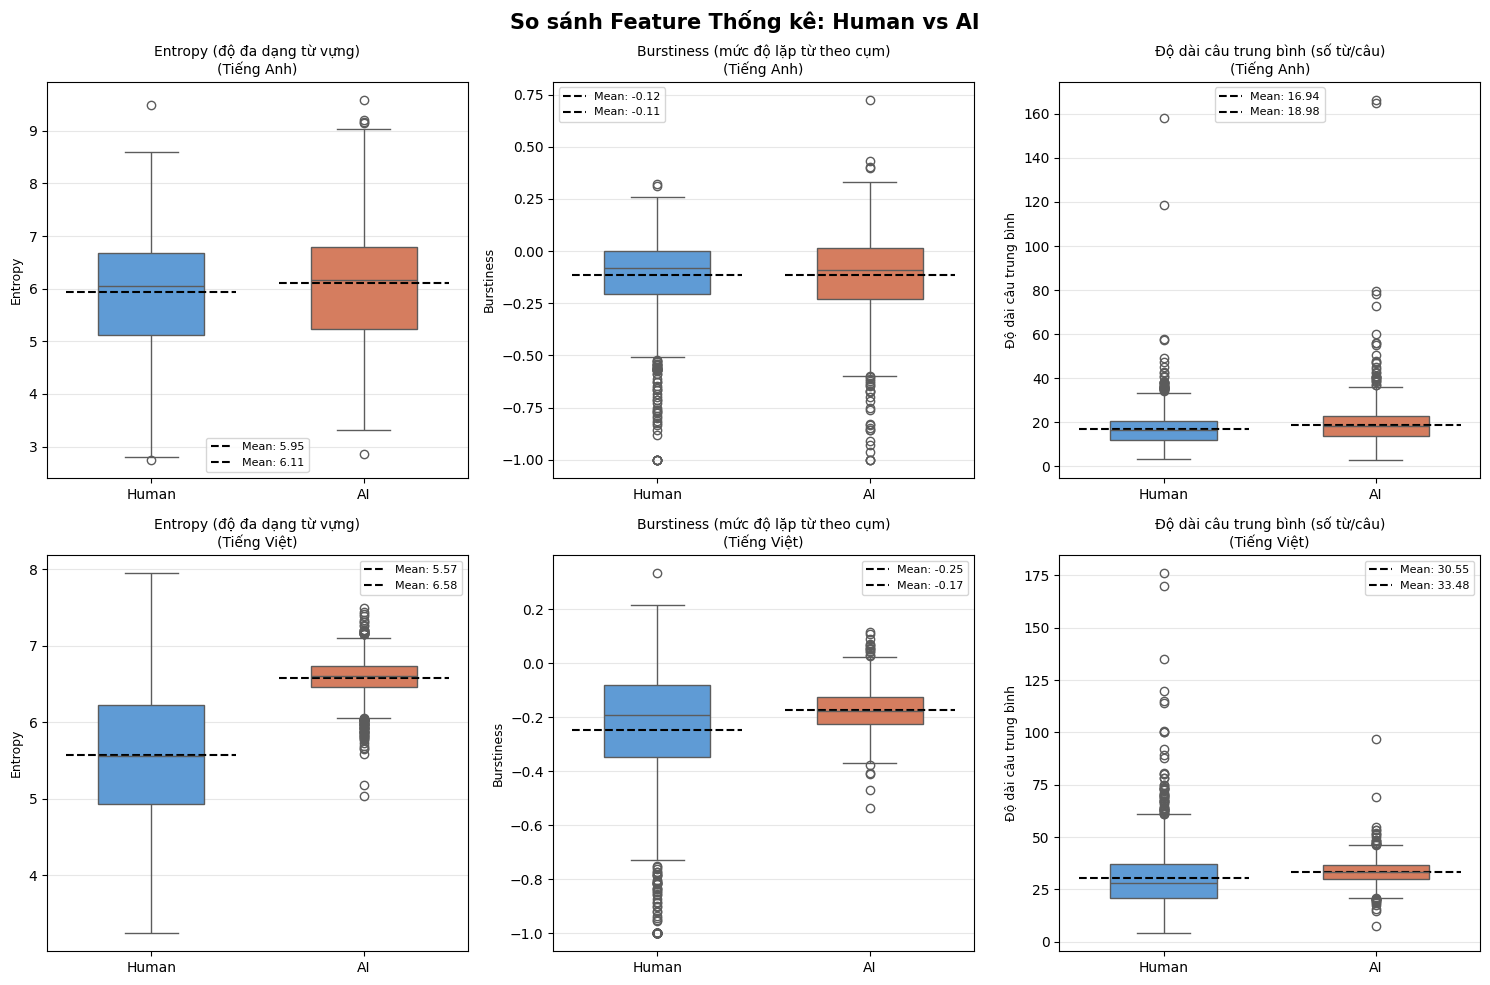

Đã lưu: feature_boxplot.png


In [6]:
# ═══════════════════════════════════════════════════════════════════
# BOXPLOT — SO SÁNH HUMAN VS AI THEO TỪNG FEATURE VÀ NGÔN NGỮ
# ═══════════════════════════════════════════════════════════════════
feature_labels = {
    "entropy":         "Entropy (độ đa dạng từ vựng)",
    "burstiness":      "Burstiness (mức độ lặp từ theo cụm)",
    "avg_sent_length": "Độ dài câu trung bình (số từ/câu)",
}
palette = {"Human": "#4C9BE8", "AI": "#E8734C"}

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("So sánh Feature Thống kê: Human vs AI",
             fontsize=15, fontweight="bold")

for col_idx, (feat, feat_label) in enumerate(feature_labels.items()):
    for row_idx, lang in enumerate(["en", "vi"]):
        ax  = axes[row_idx][col_idx]
        sub = feat_df[feat_df["language"] == lang]
        sns.boxplot(data=sub, x="label_name", y=feat,
                    palette=palette, width=0.5,
                    order=["Human", "AI"], ax=ax)
        ax.set_title(f"{feat_label}\n({'Tiếng Anh' if lang=='en' else 'Tiếng Việt'})",
                     fontsize=10)
        ax.set_xlabel("")
        ax.set_ylabel(feat_label.split("(")[0].strip(), fontsize=9)
        # Đường trung bình
        for i, group in enumerate(["Human", "AI"]):
            mean_val = sub[sub["label_name"] == group][feat].mean()
            ax.hlines(mean_val, i-0.4, i+0.4, colors="black",
                      linestyles="--", linewidth=1.5,
                      label=f"Mean: {mean_val:.2f}")
        ax.legend(fontsize=8)
        ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("feature_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Đã lưu: feature_boxplot.png")

---
## Phần 2 — Attention Visualization
Trả lời: *"Model đang dựa vào token nào để đưa ra quyết định?"*

Làm cho cả 2 model:
- **XLM-R**: xử lý cả EN lẫn VI bằng 1 model
- **Hybrid**: EN dùng RoBERTa, VI dùng PhoBERT

In [7]:
# ═══════════════════════════════════════════════════════════════════
# LOAD CẢ 3 MODEL (output_attentions=True để lấy attention)
# ═══════════════════════════════════════════════════════════════════
def load_model(model_dir):
    tok   = AutoTokenizer.from_pretrained(model_dir)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_dir, output_attentions=True
    ).to(device)
    model.eval()
    return tok, model

print("Loading XLM-RoBERTa...")
tok_xlm, model_xlm = load_model(XLM_MODEL_DIR)

print("Loading RoBERTa (EN)...")
tok_ro, model_ro = load_model(RO_MODEL_DIR)

print("Loading PhoBERT (VI)...")
tok_ph, model_ph = load_model(PH_MODEL_DIR)

print("\nĐã load xong 3 model!")

Loading XLM-RoBERTa...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading RoBERTa (EN)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading PhoBERT (VI)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Đã load xong 3 model!


In [8]:
# ═══════════════════════════════════════════════════════════════════
# HÀM LẤY ATTENTION SCORES — nhận model/tokenizer làm tham số
# ═══════════════════════════════════════════════════════════════════
def get_attention_scores(text, tok, model, segment=False, max_len=128):
    """
    Trả về:
    - tokens     : danh sách token
    - scores     : attention score trung bình mỗi token
                   (layer cuối, trung bình qua tất cả heads)
    - pred_label : nhãn dự đoán (0=Human, 1=AI)
    - pred_prob  : xác suất dự đoán
    """
    if segment:
        text = word_tokenize(text, format="text")   # PhoBERT cần tách từ

    enc = tok(text, max_length=max_len, truncation=True, return_tensors="pt")
    input_ids      = enc["input_ids"].to(device)
    attention_mask = enc["attention_mask"].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

    probs      = F.softmax(outputs.logits, dim=-1)[0]
    pred_label = probs.argmax().item()
    pred_prob  = probs[pred_label].item()

    # Layer cuối, trung bình qua heads, lấy hàng CLS (index 0)
    last_attn = outputs.attentions[-1]          # (1, heads, seq, seq)
    cls_attn  = last_attn[0, :, 0, :]          # (heads, seq)
    avg_attn  = cls_attn.mean(dim=0).cpu().numpy()  # (seq,)

    seq_len = attention_mask.sum().item()
    tokens  = tok.convert_ids_to_tokens(input_ids[0][:seq_len])
    scores  = avg_attn[:seq_len]
    return tokens, scores, pred_label, pred_prob


def plot_attention_bar(text, true_label, tok, model,
                       ax, model_name, segment=False, max_tokens=25):
    """Vẽ bar chart attention score cho một mẫu."""
    tokens, scores, pred_label, pred_prob = get_attention_scores(
        text, tok, model, segment=segment
    )
    # Bỏ special tokens
    special = {"<s>", "</s>", "<pad>", "▁", "[CLS]", "[SEP]", "[PAD]"}
    pairs   = [(t, s) for t, s in zip(tokens, scores) if t not in special]
    pairs   = pairs[:max_tokens]
    if not pairs:
        return
    disp_tokens = [t for t, _ in pairs]
    disp_scores = np.array([s for _, s in pairs])
    if disp_scores.max() > 0:
        disp_scores = disp_scores / disp_scores.max()

    colors = plt.cm.Reds(disp_scores * 0.8 + 0.2)
    ax.bar(range(len(disp_tokens)), disp_scores, color=colors)
    ax.set_xticks(range(len(disp_tokens)))
    ax.set_xticklabels(disp_tokens, rotation=45, ha="right", fontsize=7)
    ax.set_ylabel("Attention", fontsize=8)
    ax.grid(axis="y", alpha=0.3)

    true_name = "Human" if true_label == 0 else "AI"
    pred_name = "Human" if pred_label == 0 else "AI"
    correct   = "✓" if true_label == pred_label else "✗"
    color_t   = "green" if true_label == pred_label else "red"
    ax.set_title(
        f"[{model_name}] {correct} Thực tế: {true_name} | Dự đoán: {pred_name} ({pred_prob:.2f})",
        fontsize=8, color=color_t, fontweight="bold"
    )


print("Đã định nghĩa hàm attention.")

Đã định nghĩa hàm attention.


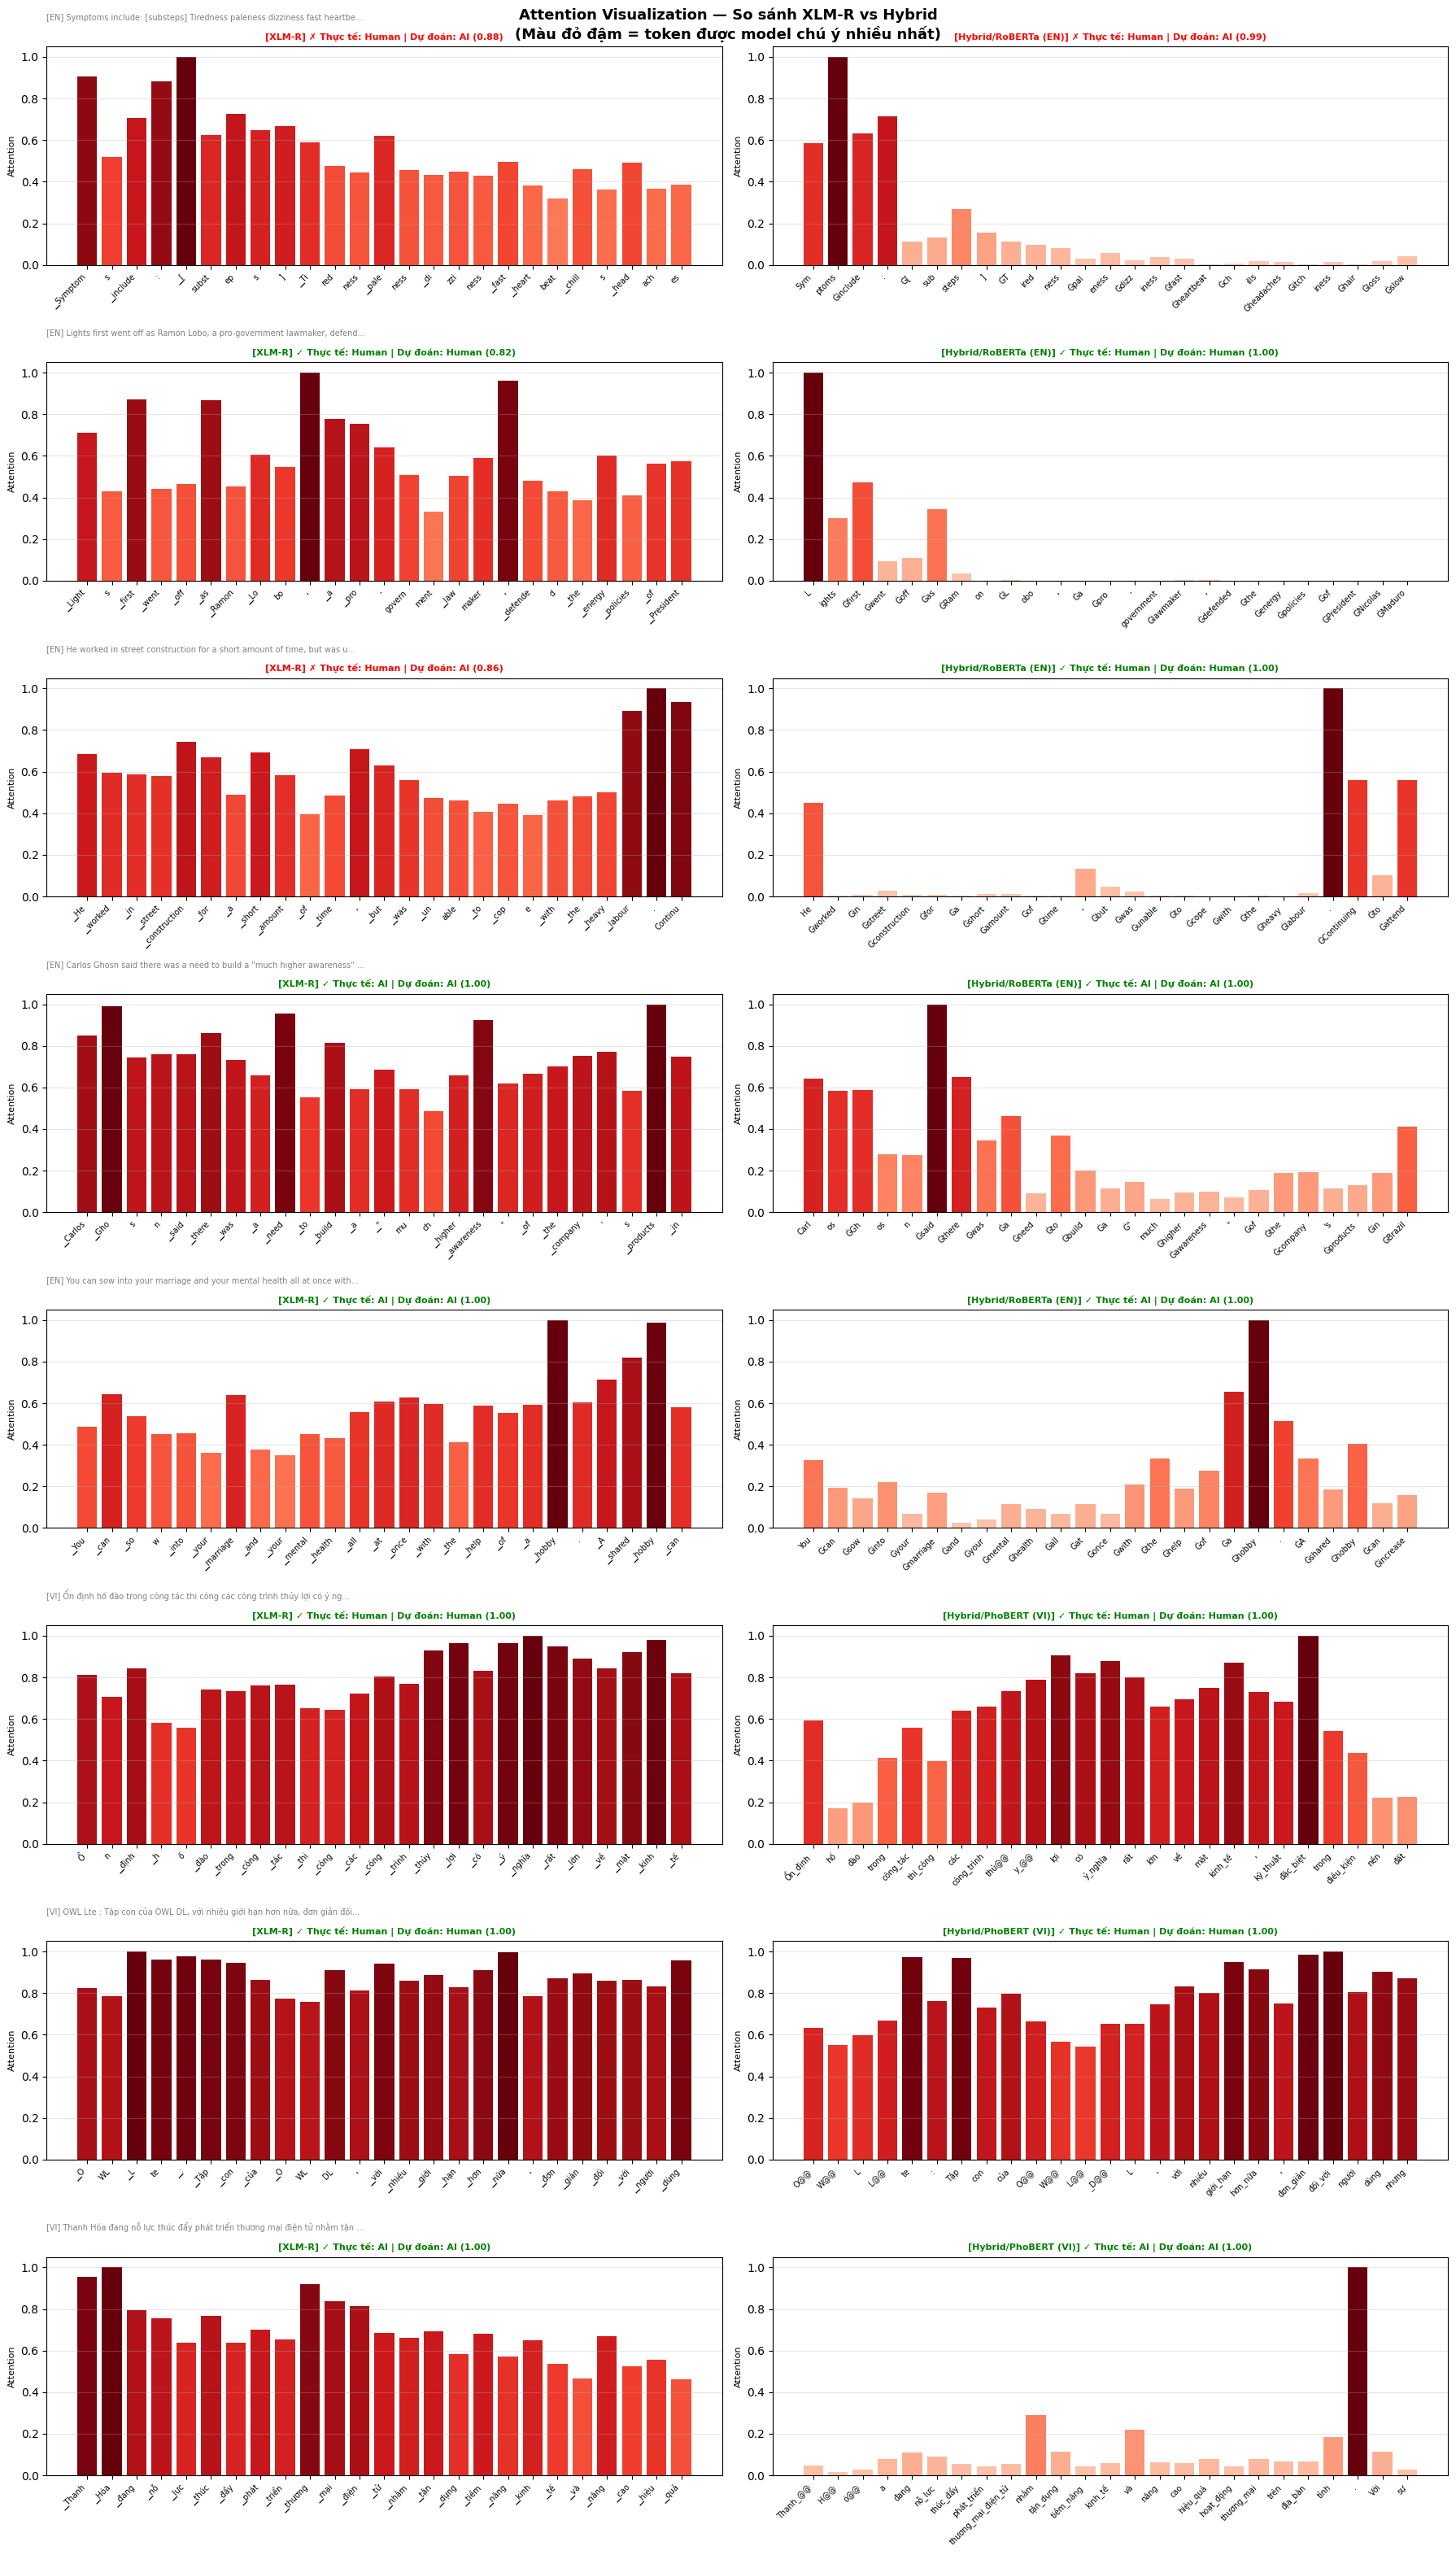

Đã lưu: attention_comparison.png


In [9]:
# ═══════════════════════════════════════════════════════════════════
# VISUALIZE ATTENTION — SO SÁNH 2 MODEL CẠNH NHAU
#
# Mỗi hàng = 1 mẫu văn bản
# Cột trái  = XLM-R
# Cột phải  = Hybrid (RoBERTa nếu EN, PhoBERT nếu VI)
# ═══════════════════════════════════════════════════════════════════
# Chọn mẫu: 3 EN (Human, AI, Human bị predict sai) + 2 VI (Human, AI)
vis_en = pd.concat([
    test_en_df[test_en_df["label"] == 0].sample(3, random_state=SEED),
    test_en_df[test_en_df["label"] == 1].sample(2, random_state=SEED),
]).reset_index(drop=True)

vis_vi = pd.concat([
    test_vi_df[test_vi_df["label"] == 0].sample(2, random_state=SEED),
    test_vi_df[test_vi_df["label"] == 1].sample(1, random_state=SEED),
]).reset_index(drop=True)

vis_all = pd.concat([vis_en, vis_vi]).reset_index(drop=True)
n_rows  = len(vis_all)

fig, axes = plt.subplots(n_rows, 2, figsize=(18, 4 * n_rows))
fig.suptitle(
    "Attention Visualization — So sánh XLM-R vs Hybrid\n"
    "(Màu đỏ đậm = token được model chú ý nhiều nhất)",
    fontsize=13, fontweight="bold"
)

for i, (_, row) in enumerate(vis_all.iterrows()):
    text     = str(row["text"])
    label    = row["label"]
    lang     = row["language"]
    preview  = text[:70] + "..."

    # Cột trái: XLM-R (xử lý cả EN lẫn VI)
    plot_attention_bar(text, label, tok_xlm, model_xlm,
                       axes[i][0], model_name="XLM-R")

    # Cột phải: Hybrid — chọn model theo ngôn ngữ
    if lang == "en":
        plot_attention_bar(text, label, tok_ro, model_ro,
                           axes[i][1], model_name="Hybrid/RoBERTa (EN)")
    else:
        plot_attention_bar(text, label, tok_ph, model_ph,
                           axes[i][1], model_name="Hybrid/PhoBERT (VI)",
                           segment=True)

    # Thêm preview text
    lang_tag = "[EN]" if lang == "en" else "[VI]"
    axes[i][0].text(0.0, 1.12, f"{lang_tag} {preview}",
                    transform=axes[i][0].transAxes,
                    fontsize=7, color="gray")

plt.tight_layout()
plt.savefig("attention_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Đã lưu: attention_comparison.png")

Tổng hợp top tokens từ 200 mẫu EN...


100%|██████████| 200/200 [00:05<00:00, 34.67it/s]


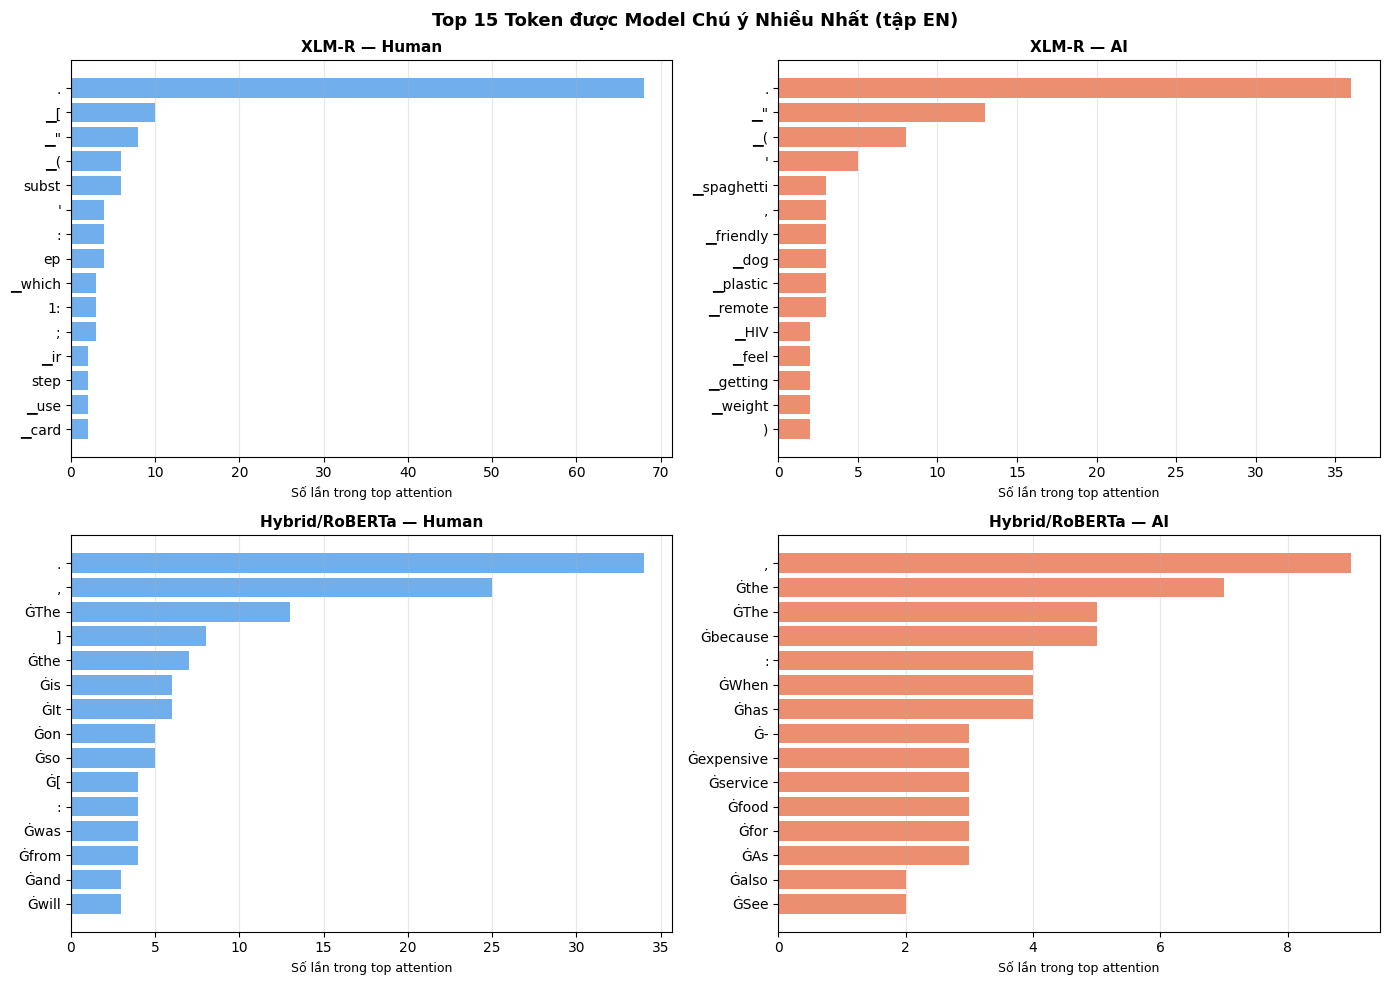

Đã lưu: top_attention_tokens.png


In [10]:
# ═══════════════════════════════════════════════════════════════════
# TOP TOKEN ĐƯỢC CHÚ Ý NHIỀU NHẤT — CẢ 2 MODEL
# Tổng hợp từ N_TOP_SAMPLES mẫu EN để so sánh
# ═══════════════════════════════════════════════════════════════════
sample_top = sample_balanced(test_en_df, N_TOP_SAMPLES)
special_tokens = {"<s>", "</s>", "<pad>", "▁", "[CLS]", "[SEP]", "[PAD]"}

# Đếm top tokens cho từng model × nhóm
counters = {
    "xlm_human": Counter(), "xlm_ai": Counter(),
    "ro_human":  Counter(), "ro_ai":  Counter(),
}

print(f"Tổng hợp top tokens từ {len(sample_top)} mẫu EN...")
for _, row in tqdm(sample_top.iterrows(), total=len(sample_top)):
    text  = str(row["text"])
    label = row["label"]
    key   = "human" if label == 0 else "ai"

    for prefix, tok, model, seg in [
        ("xlm", tok_xlm, model_xlm, False),
        ("ro",  tok_ro,  model_ro,  False),
    ]:
        tokens, scores, _, _ = get_attention_scores(text, tok, model, segment=seg)
        pairs = [(t, s) for t, s in zip(tokens, scores) if t not in special_tokens]
        pairs.sort(key=lambda x: x[1], reverse=True)
        top5 = [t for t, _ in pairs[:5]]
        counters[f"{prefix}_{key}"].update(top5)

# Vẽ: 2 hàng (XLM-R, RoBERTa) × 2 cột (Human, AI)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Top 15 Token được Model Chú ý Nhiều Nhất (tập EN)",
             fontsize=13, fontweight="bold")

configs = [
    (axes[0][0], counters["xlm_human"], "XLM-R — Human",          "#4C9BE8"),
    (axes[0][1], counters["xlm_ai"],    "XLM-R — AI",              "#E8734C"),
    (axes[1][0], counters["ro_human"],  "Hybrid/RoBERTa — Human",  "#4C9BE8"),
    (axes[1][1], counters["ro_ai"],     "Hybrid/RoBERTa — AI",     "#E8734C"),
]

for ax, counter, title, color in configs:
    top15  = counter.most_common(15)
    tokens_list = [t for t, _ in top15]
    counts_list = [c for _, c in top15]
    ax.barh(range(len(tokens_list)), counts_list, color=color, alpha=0.8)
    ax.set_yticks(range(len(tokens_list)))
    ax.set_yticklabels(tokens_list, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel("Số lần trong top attention", fontsize=9)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("top_attention_tokens.png", dpi=150, bbox_inches="tight")
plt.show()
print("Đã lưu: top_attention_tokens.png")

In [11]:
# ═══════════════════════════════════════════════════════════════════
# TÓM TẮT KẾT QUẢ
# ═══════════════════════════════════════════════════════════════════
print("━━━ TÓM TẮT KẾT QUẢ PHÂN TÍCH FEATURE ━━━")
print()
print("PHẦN 1 — Feature Thống kê:")
for lang in ["en", "vi"]:
    print(f"\n  [{lang.upper()}]")
    sub = feat_df[feat_df["language"] == lang]
    for feat in feature_cols:
        h = sub[sub["label"]==0][feat].mean()
        a = sub[sub["label"]==1][feat].mean()
        direction = "AI > Human" if a > h else "Human > AI"
        print(f"    {feat:20s}: Human={h:.3f}  AI={a:.3f}  → {direction}")

print()
print("PHẦN 2 — Attention Visualization (2 model):")
print("  attention_comparison.png  ← XLM-R vs Hybrid cạnh nhau")
print("  top_attention_tokens.png  ← top tokens của cả 2 model")

━━━ TÓM TẮT KẾT QUẢ PHÂN TÍCH FEATURE ━━━

PHẦN 1 — Feature Thống kê:

  [EN]
    entropy             : Human=5.946  AI=6.108  → AI > Human
    burstiness          : Human=-0.116  AI=-0.114  → AI > Human
    avg_sent_length     : Human=16.942  AI=18.978  → AI > Human

  [VI]
    entropy             : Human=5.573  AI=6.578  → AI > Human
    burstiness          : Human=-0.247  AI=-0.173  → AI > Human
    avg_sent_length     : Human=30.545  AI=33.477  → AI > Human

PHẦN 2 — Attention Visualization (2 model):
  attention_comparison.png  ← XLM-R vs Hybrid cạnh nhau
  top_attention_tokens.png  ← top tokens của cả 2 model
